## Retail Marketing A/B Testing Analysis

### Business Problem

A retail company wants to understand whether showing ads to users actually
increases conversions and sales. The company conducted an A/B test where:

- Control Group = PSA (Public Service Announcement)
- Test Group = Ad Campaign

The goal is to determine whether the advertising campaign performs better
than the control group and identify factors affecting conversions.

### Research Problem

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

### Data Description

In [2]:
# Loading the Dataset
df = pd.read_csv('marketing_AB.csv')

# data overview
print(df.head())

   Unnamed: 0  user id test group  converted  total ads most ads day  \
0           0  1069124         ad      False        130       Monday   
1           1  1119715         ad      False         93      Tuesday   
2           2  1144181         ad      False         21      Tuesday   
3           3  1435133         ad      False        355      Tuesday   
4           4  1015700         ad      False        276       Friday   

   most ads hour  
0             20  
1             22  
2             18  
3             10  
4             14  


In [3]:
# Shape
print(df.shape)

(588101, 7)


In [5]:
# Data Info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB
None


In [6]:
# Missing Values
print(df.isnull().sum())

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64


In [7]:
# Statistical Summary
print(df.describe)

<bound method NDFrame.describe of         Unnamed: 0  user id test group  converted  total ads most ads day  \
0                0  1069124         ad      False        130       Monday   
1                1  1119715         ad      False         93      Tuesday   
2                2  1144181         ad      False         21      Tuesday   
3                3  1435133         ad      False        355      Tuesday   
4                4  1015700         ad      False        276       Friday   
...            ...      ...        ...        ...        ...          ...   
588096      588096  1278437         ad      False          1      Tuesday   
588097      588097  1327975         ad      False          1      Tuesday   
588098      588098  1038442         ad      False          3      Tuesday   
588099      588099  1496395         ad      False          1      Tuesday   
588100      588100  1237779         ad      False          1      Tuesday   

        most ads hour  
0                

In [8]:
# Count users in each group
print(df['test group'].value_counts())

ad     564577
psa     23524
Name: test group, dtype: int64


### Comparing Campaigns Performance

test group
ad     2.554656
psa    1.785411
Name: converted, dtype: float64


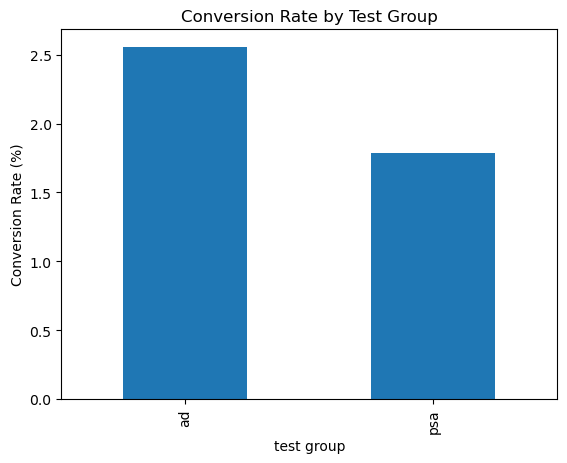

In [12]:
# Conversion Rate Comparison

conversion_rate = df.groupby('test group')['converted'].mean() * 100
print(conversion_rate)

# Plot
conversion_rate.plot(kind='bar')
plt.title('Conversion Rate by Test Group')
plt.ylabel('Conversion Rate (%)')
plt.show()

The ad campaign group shows a higher conversion rate compared to the PSA group,
indicating that advertisements positively influence customer conversions.

### Which days generate higher conversions compared to other days?

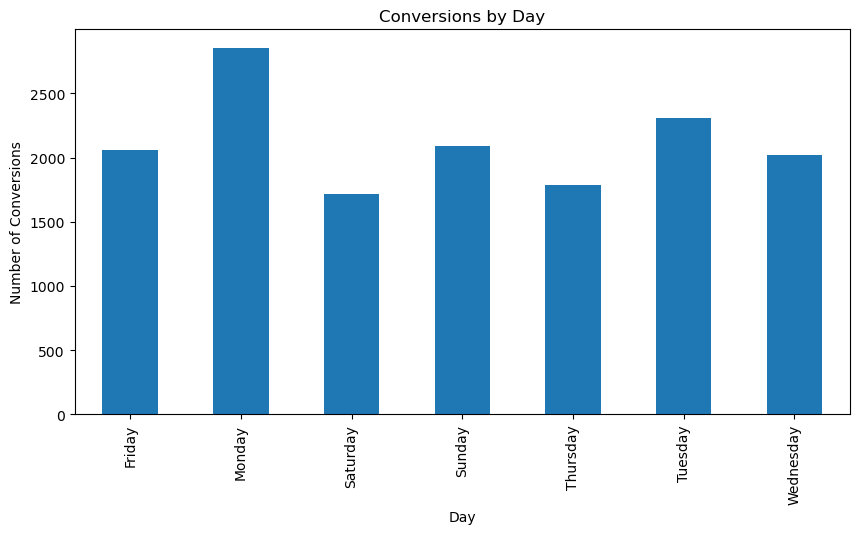

In [15]:
#conversions by day
day_conversion = df.groupby('most ads day')['converted'].sum()

plt.figure(figsize=(10,5))
day_conversion.plot(kind='bar')

plt.title('Conversions by Day')
plt.xlabel('Day')
plt.ylabel('Number of Conversions')
plt.show()

### Do users who see more ads have a higher chance of conversion?

converted
False    23.291495
True     83.887759
Name: total ads, dtype: float64


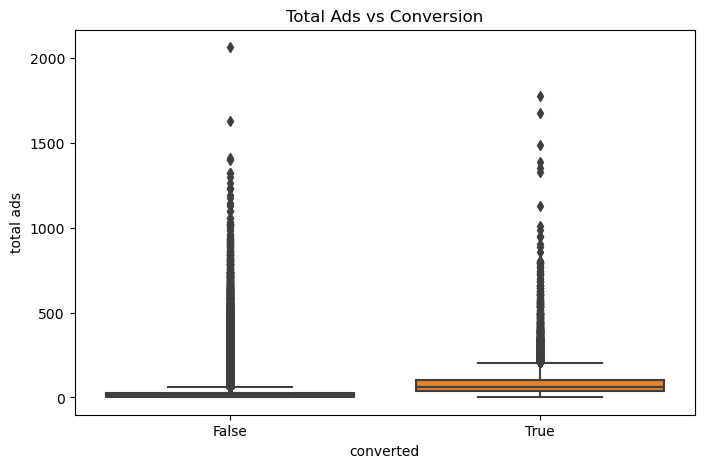

In [16]:
# Ads vs Conversion

ads_conversion = df.groupby('converted')['total ads'].mean()
print(ads_conversion)

# Scatter Plot
plt.figure(figsize=(8,5))
sns.boxplot(x='converted', y='total ads', data=df)
plt.title('Total Ads vs Conversion')
plt.show()

### Hypothesis Testing

In [17]:
# Separate Groups
ad_group = df[df['test group'] == 'ad']['converted'].astype(int)
psa_group = df[df['test group'] == 'psa']['converted'].astype(int)

# T-Test
stat, p_value = ttest_ind(ad_group, psa_group)

print('T-Statistic:', stat)
print('P-Value:', p_value)

T-Statistic: 7.37040597428566
P-Value: 1.7033052627831264e-13


Null Hypothesis(H0):- There is no significant difference between Ad and PSA groups.
Alternate Hypothesis(H1):- There is a significant difference in conversion rates between the Ad group and PSA group.

#### Regression Analysis By Using Logistic Regression

In [18]:
# Predicting customer conversions using Logistic Regression
# 9. Logistic Regression Analysis

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Convert Boolean Values into Integer
df['converted_int'] = df['converted'].astype(int)

# Features and Target Variable
X = df[['total ads']]
y = df['converted_int']

In [19]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
# Logistic Regression Model
model = LogisticRegression()

# Train Model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

In [21]:
# Model Evaluation
print("Accuracy Score:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.9733976075700768

Confusion Matrix:
[[114453    179]
 [  2950     39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99    114632
           1       0.18      0.01      0.02      2989

    accuracy                           0.97    117621
   macro avg       0.58      0.51      0.51    117621
weighted avg       0.95      0.97      0.96    117621



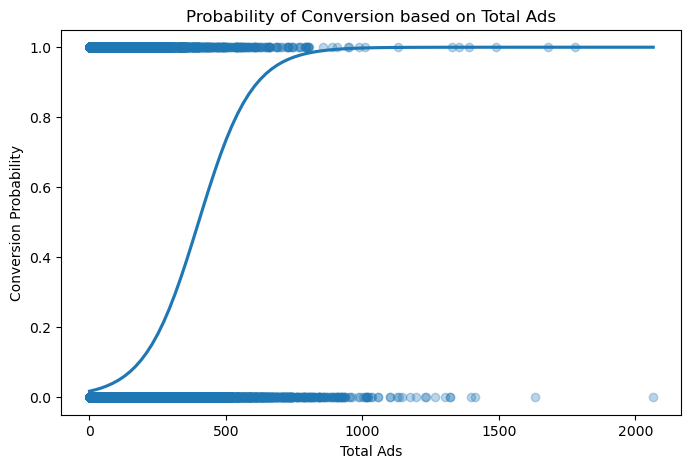

In [26]:
# Logistic Regression Visualization
plt.figure(figsize=(8,5))

sns.regplot(
    x='total ads',
    y='converted_int',
    data=df,
    logistic=True,
    ci=None,
    scatter_kws={'alpha':0.3},)

plt.title('Probability of Conversion based on Total Ads')
plt.xlabel('Total Ads')
plt.ylabel('Conversion Probability')
plt.show()

Logistic Regression is used because the target variable 'converted' contains binary values (True/False).
The model helps predict whether a customer is likely to convert based on the number of advertisements viewed.
This analysis shows the relationship between ad exposure and customer conversion behavior.

### Time-Based Analysis of Retail Marketing Campaign

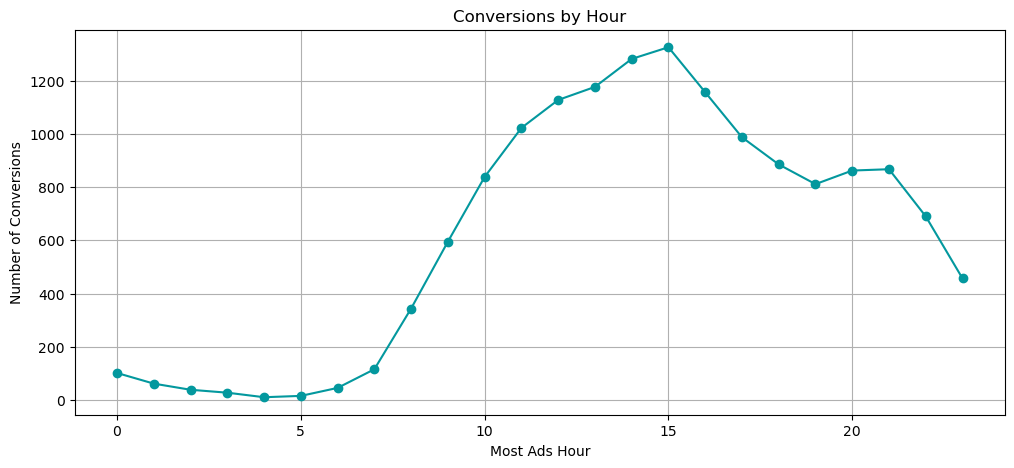

In [24]:
# Conversion by Hour
hour_conversion = df.groupby('most ads hour')['converted'].sum()
plt.figure(figsize=(12,5))

hour_conversion.plot(
    kind='line',
    marker='o',
    color='#03989E')

plt.title('Conversions by Hour')
plt.xlabel('Most Ads Hour')
plt.ylabel('Number of Conversions')
plt.grid(True)
plt.show()

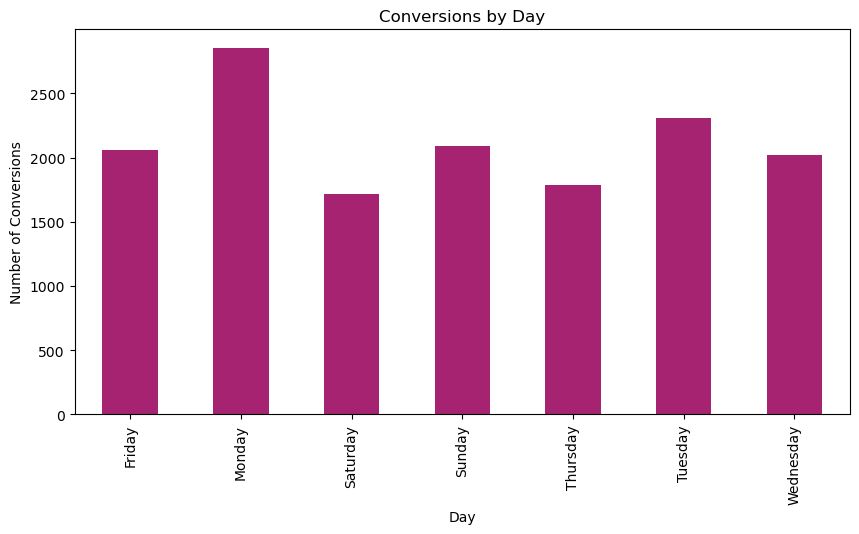

In [25]:
# Conversion by Day
day_conversion = df.groupby('most ads day')['converted'].sum()
plt.figure(figsize=(10,5))

day_conversion.plot(
    kind='bar',
    color='#A62372')

plt.title('Conversions by Day')
plt.xlabel('Day')
plt.ylabel('Number of Conversions')
plt.show()

The analysis shows that customer conversions vary across  different hours and days.

Certain hours generate higher conversions, indicating peak customer engagement periods.

Similarly, some days perform better than others,helping businesses identify the most effective time for running marketing campaigns.

## Conclusion